In [2]:
import pykasso as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go
import networkx as nx
import importlib
import seaborn as sns
import os
import sys
import gempy as gp
import gempy_viewer as gpv
import contextily as cx
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
from matplotlib_scalebar.scalebar import ScaleBar
import random
# import cfpy

Setting Backend To: AvailableBackends.numpy


In [32]:
import utils.common
import utils.conduits
import utils.openkarst_network
import utils.geos
importlib.reload(utils.openkarst_network)
importlib.reload(utils.common)
importlib.reload(utils.geos)
importlib.reload(utils.conduits)
from utils.common import *
from utils.geos import * 
from utils.conduits import *
import utils.openkarst_network as okn


In [4]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

# Generate Single Straight Line Conduit

In [20]:
nodes = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/nodes.csv')
edges = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/edges.csv')

In [21]:
plot_3D_network(nodes, edges, node_color='type')

In [24]:
edges['length'] = np.sqrt((edges.x_0 - edges.x_1)**2 + (edges.y_0 - edges.y_1)**2 + (edges.z_0 - edges.z_1)**2)

# Generate Straight Line Multi-conduit Network

In [152]:
new_nodes = pd.read_csv('../../data/networks/multiconduit/straight_n5/nodes.csv', index_col=False)
new_edges = pd.read_csv('../../data/networks/multiconduit/straight_n5/edges.csv', index_col=False)
new_edges = extract_edge_coordinates(new_nodes, new_edges)
new_nodes, new_edges = densify_edges(new_nodes, new_edges, density_factor=1)
new_nodes, new_edges = reset_node_ids(new_nodes, new_edges)

In [155]:
new_nodes.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/n_12/nodes.csv', index = False)
new_edges.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/n_12/edges.csv', index = False)

# Generate Geologic Model

In [11]:
nx = grid_parameters['nx']
ny = grid_parameters['ny']
nz = grid_parameters['nz']
geo = np.random.randint(1, 3, size = (nx, ny, nz))
geology_costs = {1 : 0.01,
                 2 : .8}
geology_model = { 1 : True, 2 : True}


In [14]:
from scipy.ndimage import gaussian_filter

field = np.random.rand(nx, ny, nz)
smooth_field = gaussian_filter(field, sigma=5)

geo = np.where(smooth_field > 0.5, 1, 2)

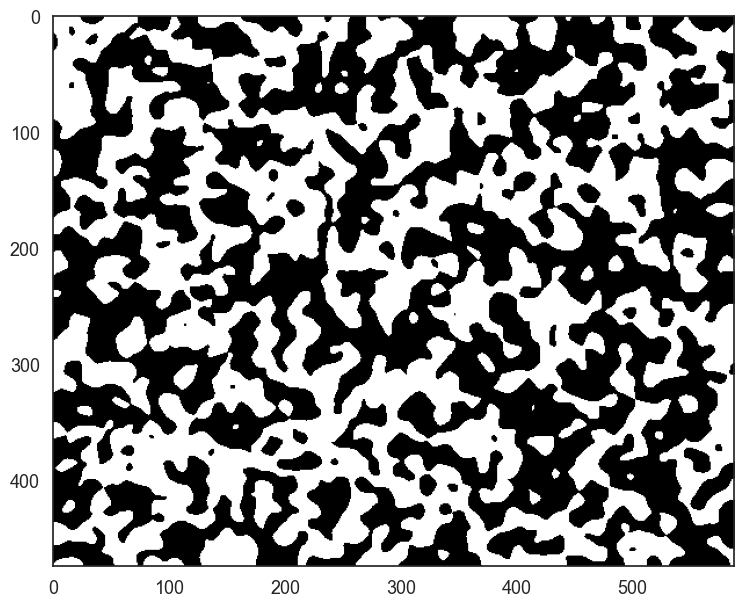

In [15]:
plt.imshow(np.flipud(geo[:,:,0].T))

# Generate Network with PyKasso

In [16]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

In [17]:
app = pk.pykasso()
# Create a new project and declare its parameters
app.new_project(name=name, grid_parameters=grid_parameters)
app.visualizer.notebook = True
nx, ny, nz = app.project.grid.shape

In [18]:
settings = 'dye_trace'

In [271]:
DEM_path = '../../data/DEM/dem_1m_m.bil'
crs = 'EPSG:32615'
grid = read_DEM_data(DEM_path, x0, x1, y0, y1, dx, dy, crs)

In [19]:
azimuth = 350
dip = 0 #np.pi/180/5
slope = np.tan(dip)
azimuth_rad = np.radians(azimuth)
dz_dx = slope * np.cos(azimuth_rad)  # Change in Z per unit X
dz_dy = slope * np.sin(azimuth_rad)  # Change in Z per unit Y
x, y = np.meshgrid(np.arange(nx), np.arange(ny))
grid = z1 - ((nx - x-1)* dx * dz_dx) + ((ny - y-1) * dy * dz_dy)

In [64]:
bedrock = grid - 3#assume bedrock is right below surface

In [20]:
# top = np.load('../../data/DEM/dem_grid_bear_spring.npy')
# model_parameters[settings]['domain']['topography'] = grid.T
model_parameters[settings]['geology'] = {
        'data' : geo,
        'costs' : geology_costs,
        'model' : geology_model
    }
# model_parameters[settings]['domain']['water_table'] = grid.T - 4
# model_parameters[settings]['domain']['bedrock'] = bedrock.T

In [21]:
for i in range(1):
    app.model.generate(model_parameters[settings])
    # print(app.model.model_parameters['sks']['seed'])


In [22]:
edges = pd.DataFrame.from_dict(app.model.vectors['edges'], orient = 'index')
nodes = pd.DataFrame.from_dict(app.model.vectors['nodes'], orient ='index')
nodes.columns = ['x', 'y', 'z', 'type']
nodes = nodes.reset_index().rename({'index':'id'}, axis=1)
# nodes['z'] = 395 # set all nodes to the same elevation to create a 2D network
edges.columns = ['from_id', 'to_id']
edges = extract_edge_coordinates(nodes, edges)

In [23]:
nodes, edges = reduce_node_density(nodes, edges, 10)
nodes, edges = reset_node_ids(nodes, edges)
edges = extract_edge_coordinates(nodes, edges)
network = okn.OpenKarstNetwork(nodes = nodes, edges = edges)
network.load_cave_data()

net : <openpnm.network.Network at 0x134b91d1010>

c:\Users\huan1428\.conda\envs\pyKasso\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning:

Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.



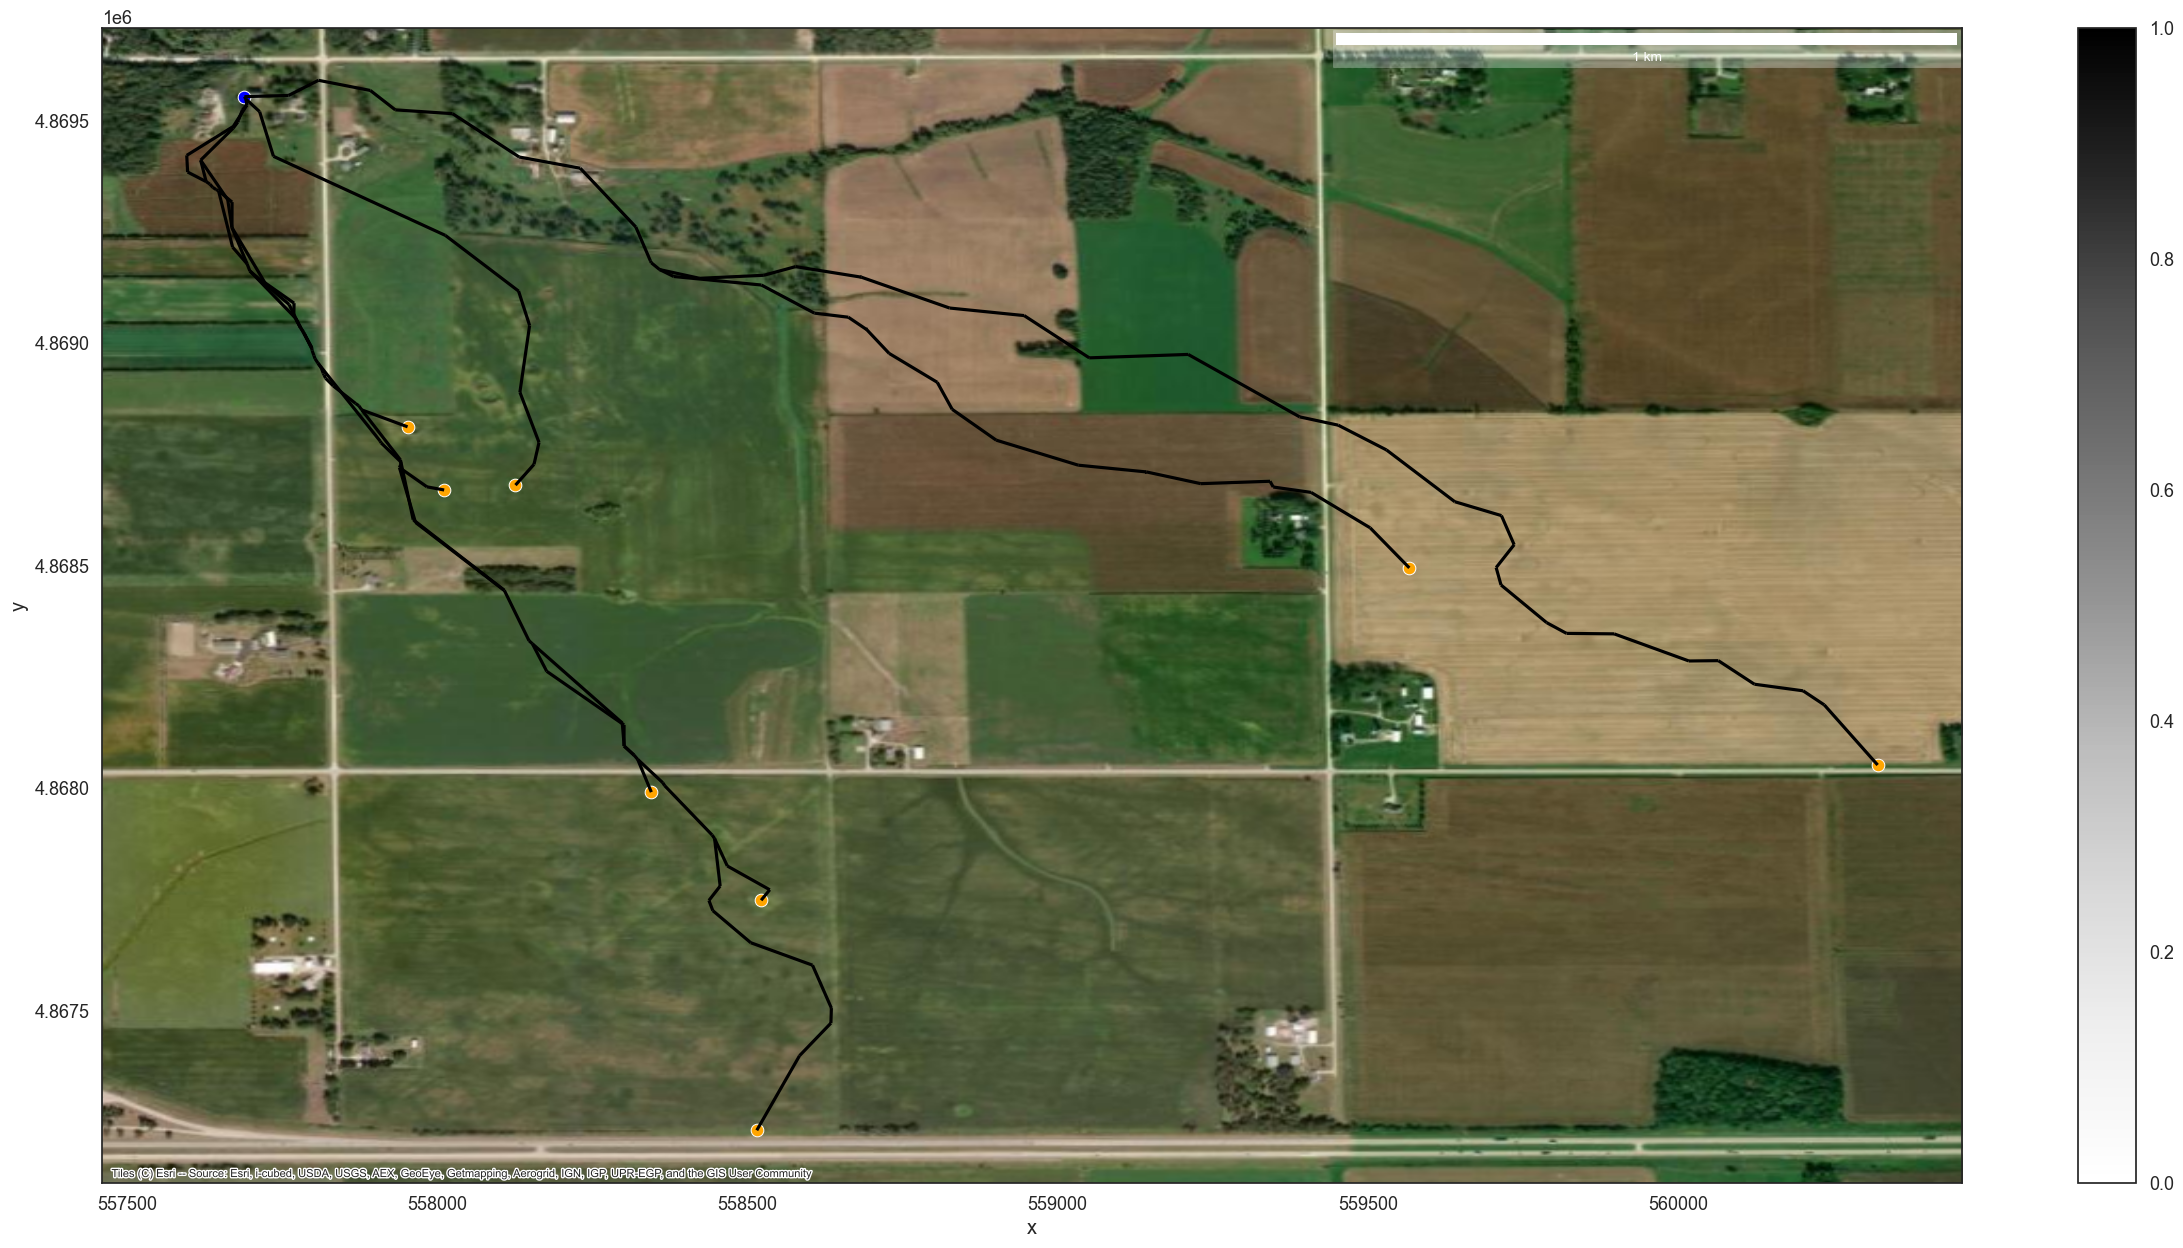

In [25]:
fig, ax = plt.subplots(figsize = (30,15))
plot_2D_network(nodes, edges, grid = False, ax =ax )
# springshed = load_geojson('../../data/geo_data/Bear_Springshed.geojson')
# sinkholes = pd.read_csv('../../data/geo_data/sinkholes/sinkholes_dye_trace_2d.csv', header = None)
# spring = pd.read_csv('../../data/geo_data/springs/springs_coords.txt', delimiter = ' ', header = None)

# springshed.plot(ax= ax, alpha = 0.6, color = 'grey')
sns.scatterplot(nodes[(nodes.type == 'outlet')], x = 'x', y = 'y', color = 'blue')
sns.scatterplot(nodes[(nodes.type == 'inlet')], x = 'x', y = 'y', color = 'orange')

source = cx.providers.Esri.WorldImagery
scalebar= ScaleBar(1, fixed_units = 'km', fixed_value = 1, box_alpha = 0.3, color = 'white')
ax.add_artist(scalebar)
# sns.scatterplot(ax = ax, data = nodes[nodes.type == 'outfall'], x= 'x', y ='y', color = 'blue', label = 'spring')
cx.add_basemap(
    ax, 
    crs='EPSG:32615', 
    source=source, 
    zoom="auto"
)
# plt.savefig('test_fig', transparent = True)

In [24]:
plot_3D_network(nodes, edges, node_color = 'type')

<Axes: >

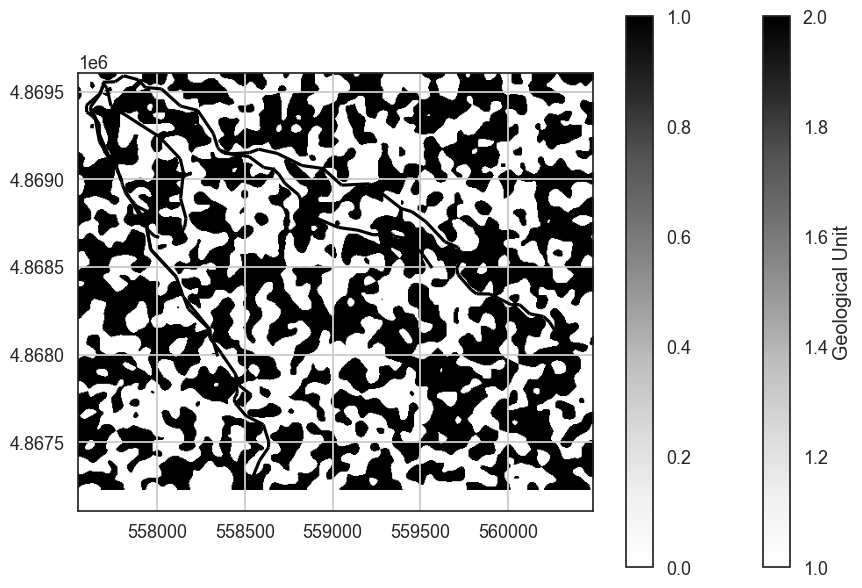

In [26]:
fig, ax = plt.subplots()
cbar = ax.imshow(np.flipud(geo[:,:,0].T), extent = (x0, x1, y0, y1))
plt.colorbar(cbar, ax = ax, label = 'Geological Unit')
plot_2D_network(nodes, edges, ax = ax, axes = ('x', 'y'))

<Axes: >

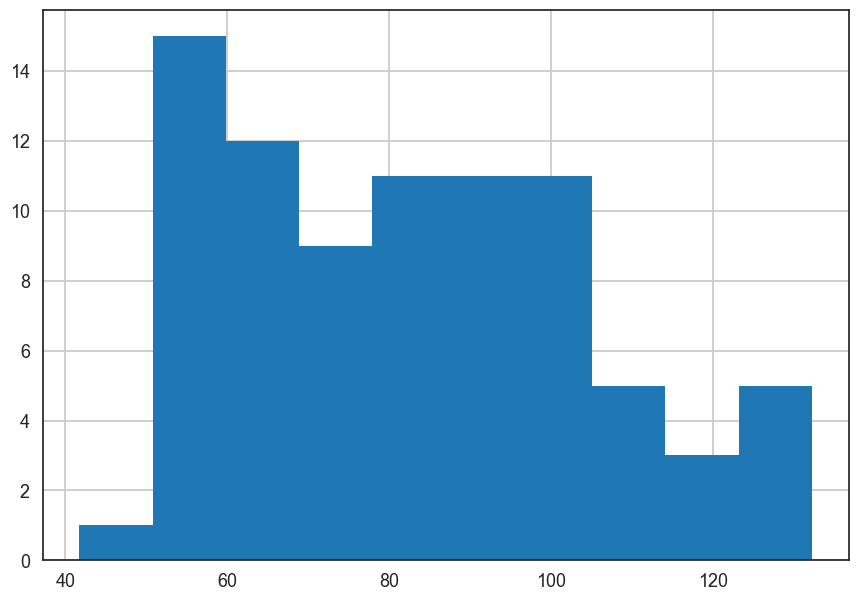

In [74]:
new_nodes, new_edges = change_node_density(nodes, edges, 100, tol = .1)
new_edges = extract_edge_coordinates(new_nodes, new_edges)
new_edges = conduit_lengths(new_nodes, new_edges)
new_edges.length.hist()

In [ ]:
from shapely.geometry import LineString

def check_intersection(edge1, edge2, tol = 1e-6):
    line1 = LineString([(edge1[0], edge1[1], edge1[2]), (edge1[3], edge1[4], edge1[5])])
    line2 = LineString([(edge2[0], edge2[1], edge2[2]), (edge2[3], edge2[4], edge2[5])])
    return line1.intersects(line2) and line1.intersection(line2).length > tol
    # Unpack edge coordinates

In [116]:
max_length = edges.length.max()
checked_edges = set() # keep track of edges that have already been checked for intersection to avoid redundant checks
for idx, edge in edges.iterrows():
    checked_edges.add(idx)
    edge_coord = edge[['x_0', 'y_0', 'z_0', 'x_1', 'y_1', 'z_1']].values #edge coordinates
    edge_midpoint = [(edge.x_0 + edge.x_1)/2, (edge.y_0 + edge.y_1)/2, (edge.z_0 + edge.z_1)/2]
    #bounding box, limited by the max conduit length of system 
    bounds = {'x_0': min(edge.x_0, edge.x_1) - max_length, 'x_1': max(edge.x_0, edge.x_1) + max_length,
              'y_0': min(edge.y_0, edge.y_1) - max_length, 'y_1': max(edge.y_0, edge.y_1) + max_length,
              'z_0': min(edge.z_0, edge.z_1) - max_length, 'z_1': max(edge.z_0, edge.z_1) + max_length}
    #only nodes within the bounding box will be tested
    nodes_to_test = nodes[((nodes.x >= bounds['x_0']) & (nodes.x <= bounds['x_1']) &
                           (nodes.y >= bounds['y_0']) & (nodes.y <= bounds['y_1']) &
                           (nodes.z >= bounds['z_0']) & (nodes.z <= bounds['z_1']))]
    nodes_to_test = nodes_to_test[(nodes_to_test.id.isin([edge.from_id, edge.to_id]) == False)]
    edges_to_test = edges[edges.from_id.isin(nodes_to_test.id) | edges.to_id.isin(nodes_to_test.id)]
    edges_to_test = edges_to_test[~edges_to_test.index.isin(checked_edges)] #exclude edges that have already been tested in previous iterations
    for test_idx, test_edge in edges_to_test.iterrows():
        test_edge_coord = test_edge[['x_0', 'y_0', 'z_0', 'x_1', 'y_1', 'z_1']].values
        if check_intersection(edge_coord, test_edge_coord):
            print(f"Edge {edge.name} intersects with edge {test_edge.name}")

(557500.0, 558500.0)

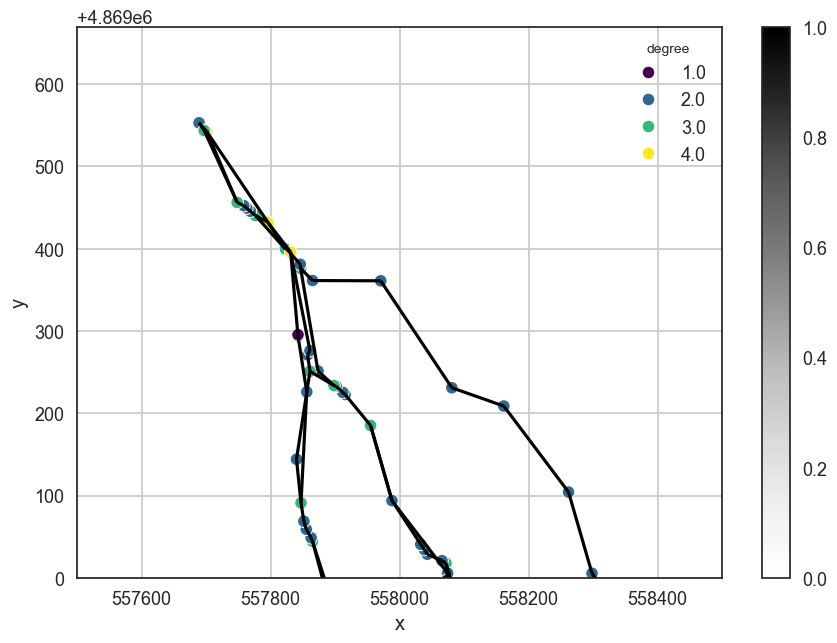

In [126]:
plot_2D_network(nodes, edges, axes = ('x', 'y'),node_color = nodes.degree)
plt.ylim(4869000,)
plt.xlim(557500,558500)


## Changing Slope

In [56]:
network_dir = '../steady_state/conduit_geometry_test/networks/pykasso_n58'
nodes = pd.read_csv(f"{network_dir}/nodes.csv")
edges = pd.read_csv(f"{network_dir}/edges.csv")
edges = conduit_lengths(nodes, edges)
edges = conduit_slopes(nodes, edges)

In [27]:
slope = 0.0008
dip = np.arctan(slope)
elevs= create_sloped_array(grid_parameters['nx'], grid_parameters['ny'], grid_parameters['dx'], grid_parameters['dy'], dip = dip, azimuth = 350, z1 = 400)

In [28]:
def calculate_azimuth(node_1, node_2):
    dx = node_1[0] - node_2[0]
    dy = node_1[1] - node_2[1]
    azimuth = np.arctan2(dy, dx)
    return azimuth

In [29]:
n1 = nodes[nodes.type =='inlet'].iloc[2][['x', 'y', 'z']]
n2 = nodes[nodes.type =='outlet'].iloc[0][['x', 'y', 'z']]
az = calculate_azimuth(n1, n2)
grid = create_sloped_array(grid_parameters['nx'], grid_parameters['ny'], grid_parameters['dx'], grid_parameters['dy'], dip = 0.1, azimuth = az, z1 = 400)
nodes, edges = project_conduit_elevations(nodes, edges, grid, x0, y1, grid_parameters['dx'], grid_parameters['dy'])
nodes.loc[nodes.type=='inlet', 'z'] = nodes.loc[nodes.type=='inlet', 'z'] + 2
edges = extract_edge_coordinates(nodes, edges)

In [33]:
network_dir = '../steady_state/conduit_geometry_test/networks'
save_network(nodes, edges, network_dir, 'anastomotic_2')


Network saved to ../steady_state/conduit_geometry_test/networks


In [30]:
plot_3D_network(nodes, edges, node_color = 'type')

In [142]:
grid_parameters

{'x0': 557546,
 'y0': 4867231,
 'z0': 390,
 'dx': 5,
 'dy': 5,
 'dz': 5,
 'nx': 588,
 'ny': 475,
 'nz': 2}

In [58]:
nodes_1, edges_1 = rescale_slope(nodes, edges, alpha = 0.1, reference_id = nodes[nodes.type == 'outlet'].id.iloc[0])

<Axes: >

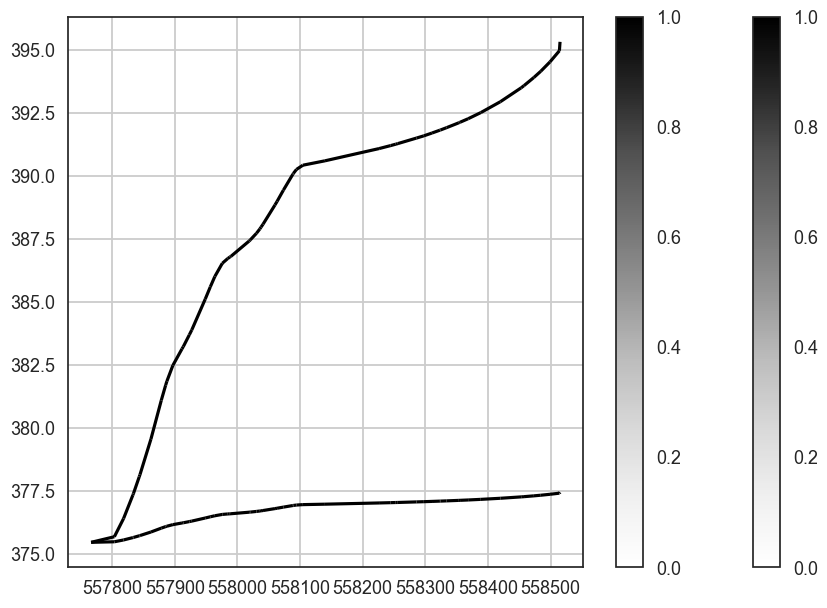

In [59]:
fig, ax = plt.subplots()
plot_2D_network(nodes, edges, axes = ('x', 'z'), ax = ax)
plot_2D_network(nodes_1, edges_1, axes = ('x', 'z'), ax = ax)

In [60]:
os.makedirs(f"{network_dir}/low_slope", exist_ok = True)
nodes_1.to_csv(f"{network_dir}/low_slope/nodes.csv", index = False)
edges_1.to_csv(f"{network_dir}/low_slope/edges.csv", index = False )

# Calculate Metrics

In [99]:
def bounding_box(nodes):
    x_min = nodes.x.min()
    x_max = nodes.x.max()
    y_min = nodes.y.min()
    y_max = nodes.y.max()
    z_min = nodes.z.min()
    z_max = nodes.z.max()
    return x_min, x_max, y_min, y_max, z_min, z_max
def bounding_box_2D(nodes):
    x_min = nodes.x.min()
    x_max = nodes.x.max()
    y_min = nodes.y.min()
    y_max = nodes.y.max()
    return x_min, x_max, y_min, y_max
def index(nodes, edges, mode, extent_method = 'bounding_box',verbose = True):
    temp_nodes = nodes.copy()
    temp_edges = edges.copy()
    if mode == 'HI':
        temp_nodes['z'] = 0 # set all nodes to the same elevation to create a 2D network
        temp_edges['z_0'] = 0
        temp_edges['z_1'] = 0
    temp_edges = conduit_lengths(temp_nodes, temp_edges)
    total_length = temp_edges.length.sum()
    print_verbose(f"Total conduit length: {total_length}", verbose)
    if extent_method == 'bounding_box':
        x_min, x_max, y_min, y_max, z_min, z_max = bounding_box(temp_nodes)
        max_extent = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2 + (z_max - z_min)**2)
        print_verbose(f"Max extent, bounding box: {max_extent}", verbose)
    elif extent_method == 'straight_line':
        max_extent = 0
        for outlet in nodes[nodes.type == 'outlet'].itertuples():
            for inlet in nodes[nodes.type == 'inlet'].itertuples():
                d = np.sqrt((outlet.x - inlet.x)**2 + (outlet.y - inlet.y)**2 + (outlet.z - inlet.z)**2)
                max_extent += d
        print_verbose(f"Max extent, straight line distance: {max_extent}", verbose)           
    #TODO: other methods
    index = total_length/max_extent
    return index

def VI(nodes, edges, extent_method = 'bounding_box', verbose = True):
    temp_nodes = nodes.copy()
    temp_edges = edges.copy()
    temp_edges = conduit_lengths(temp_nodes, temp_edges)
    total_length = temp_edges.length.sum()
    print_verbose(f"Total conduit length: {total_length}", verbose)
    if extent_method == 'bounding_box':
        x_min, x_max, y_min, y_max, z_min, z_max = bounding_box(temp_nodes)
        max_extent = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2 + (z_max - z_min)**2)
        print_verbose(f"Max extent of network: {max_extent}", verbose)
    VI = total_length/max_extent
    return VI

In [159]:
nodes = pd.read_csv("../steady_state/conduit_geometry_test/networks/anastomotic/nodes.csv")
edges = pd.read_csv("../steady_state/conduit_geometry_test/networks/anastomotic/edges.csv")
# simple_nodes, simple_edges = reduce_node_density(nodes, edges, 100)
# simple_nodes, simple_edges = reset_node_ids(simple_nodes, simple_edges)
network = okn.OpenKarstNetwork(nodes=nodes, edges = edges)
network.load_cave_data()
# simple_nodes['d'] = 1
# nodes['z'] = get_elev_from_coords(nodes.x, nodes.y, elevs, x0, y1, grid_parameters['dx'], grid_parameters['dy'])
# edges = extract_edge_coordinates(nodes, edges)
# nodes.to_csv("../steady_state/conduit_geometry_test/networks/anastomotic/nodes.csv", index = False)
# edges.to_csv("../steady_state/conduit_geometry_test/networks/anastomotic/edges.csv", index = False)

net : <openpnm.network.Network at 0x1e167477b30>

In [160]:
index(nodes, edges, mode='HI', extent_method = 'bounding_box', verbose = True)

Total conduit length: 52895.49607900424
Max extent, bounding box: 3752.0874647593464


np.float64(14.097618079486024)

In [158]:
index(nodes, edges, mode = 'VI', extent_method = 'bounding_box', verbose = True)

Total conduit length: 8098.819641687341
Max extent, bounding box: 3376.198050750857


np.float64(2.3987987434227045)

In [86]:
conduit_lengths(nodes, edges)

,from_id,to_id,x_0,y_0,z_0,x_1,y_1,z_1,length
0,0,7,558515.000000,4.867230e+06,395.320007,558491.000000,4.867299e+06,394.980483,72.605976
1,7,8,558491.000000,4.867299e+06,394.980483,558467.000000,4.867367e+06,394.640959,72.605976
2,8,9,558467.000000,4.867367e+06,394.640959,558443.000000,4.867436e+06,394.301435,72.605976
3,9,10,558443.000000,4.867436e+06,394.301435,558419.000000,4.867504e+06,393.961911,72.605976
4,10,11,558419.000000,4.867504e+06,393.961911,558395.000000,4.867573e+06,393.622387,72.605976
...,...,...,...,...,...,...,...,...,...
121,122,123,557824.520090,4.869253e+06,378.494001,557812.865096,4.869290e+06,377.888000,38.343119
122,123,124,557812.865096,4.869290e+06,377.888000,557801.210101,4.869326e+06,377.282000,38.343119
123,124,125,557801.210101,4.869326e+06,377.282000,557789.555107,4.869363e+06,376.676000,38.343119
124,125,126,557789.555107,4.869363e+06,376.676000,557777.900112,4.869399e+06,376.070000,38.343119


In [84]:
edges[['z_0', 'z_1']] = 0 
conduit_lengths(nodes, edges)

,from_id,to_id,x_0,y_0,z_0,x_1,y_1,z_1,length
0,0,7,558515.000000,4.867230e+06,0,558491.000000,4.867299e+06,0,72.605182
1,7,8,558491.000000,4.867299e+06,0,558467.000000,4.867367e+06,0,72.605182
2,8,9,558467.000000,4.867367e+06,0,558443.000000,4.867436e+06,0,72.605182
3,9,10,558443.000000,4.867436e+06,0,558419.000000,4.867504e+06,0,72.605182
4,10,11,558419.000000,4.867504e+06,0,558395.000000,4.867573e+06,0,72.605182
...,...,...,...,...,...,...,...,...,...
121,122,123,557824.520090,4.869253e+06,0,557812.865096,4.869290e+06,0,38.338330
122,123,124,557812.865096,4.869290e+06,0,557801.210101,4.869326e+06,0,38.338330
123,124,125,557801.210101,4.869326e+06,0,557789.555107,4.869363e+06,0,38.338330
124,125,126,557789.555107,4.869363e+06,0,557777.900112,4.869399e+06,0,38.338330


<Axes: >

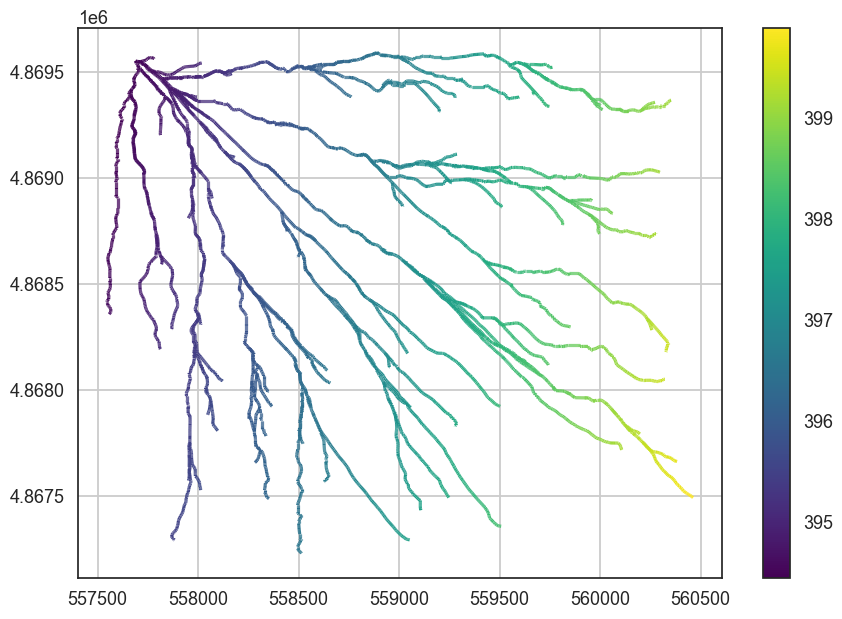

In [119]:
plot_2D_network(network.nodes, network.edges, axes = ('x', 'y'), edge_color=network.edges.z_1, palette = 'viridis')


In [162]:
plot_3D_network(network.nodes, network.edges, node_color = None)